# Project 05: Text Generation

**Category:** NLP | **Dataset:** WikiText-2 | **Model:** GPT-2

## Overview

This notebook fine-tunes **GPT-2** for causal language modeling (text generation) on WikiText-2. We use **Optuna** to search over learning rate, batch size, and weight decay before full training.

### Methodology
1. **Optuna hyperparameter search** — 5 trials × 2 epochs, minimizing perplexity
2. **Full training** — 5 epochs with best hyperparameters, early stopping
3. **Evaluation** — perplexity and generated text quality analysis

### Key Metrics
- Primary: **Perplexity** — target < 50 (lower is better)
- Secondary: Cross-entropy loss (NLL loss per token)


In [19]:
import sys
import os
import gc
import math
import torch
import numpy as np
import matplotlib.pyplot as plt
import optuna
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Add project directory to path
project_dir = os.path.abspath('05_Text_Generation')
if project_dir not in sys.path:
    sys.path.insert(0, project_dir)

# Device auto-detection: CUDA -> MPS -> CPU
def setup_device():
    if torch.cuda.is_available():
        device = torch.device('cuda')
        torch.backends.cudnn.benchmark = True
        print(f'Using CUDA: {torch.cuda.get_device_name(0)}')
    elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        device = torch.device('mps')
        print('Using Apple MPS')
    else:
        device = torch.device('cpu')
        print('Using CPU')
    return device

def get_platform_config(device):
    if device.type == 'cuda':
        return {'num_workers': 4, 'pin_memory': True, 'use_amp': True, 'amp_dtype': torch.float16}
    elif device.type == 'mps':
        return {'num_workers': 0, 'pin_memory': False, 'use_amp': True, 'amp_dtype': torch.float16}
    else:
        return {'num_workers': 2, 'pin_memory': False, 'use_amp': False, 'amp_dtype': None}

device = setup_device()
platform_config = get_platform_config(device)

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f'PyTorch version: {torch.__version__}')
print(f'Platform config: {platform_config}')


Using CUDA: NVIDIA GeForce RTX 4090
PyTorch version: 2.7.1+cu118
Platform config: {'num_workers': 4, 'pin_memory': True, 'use_amp': True, 'amp_dtype': torch.float16}


In [20]:
# Training Configuration — GPT-2 fine-tuning on WikiText-2
config = {
    'model_name': 'gpt2',
    'dataset': 'wikitext',
    'tokenizer_name': 'gpt2',
    'max_length': 256,              # sequence length for training
    'stride': 128,                  # sliding window stride
    'epochs': 5,                    # full training epochs
    'batch_size': 8,
    'learning_rate': 5e-5,
    'weight_decay': 0.01,
    'num_workers': platform_config['num_workers'],
    'pin_memory': platform_config['pin_memory'],
    'use_amp': platform_config['use_amp'],
    'checkpoint_dir': './checkpoints',
    'use_wandb': False,
}

print("Training configuration:")
for k, v in config.items():
    print(f"  {k}: {v}")


Training configuration:
  model_name: gpt2
  dataset: wikitext
  tokenizer_name: gpt2
  max_length: 256
  stride: 128
  epochs: 5
  batch_size: 8
  learning_rate: 5e-05
  weight_decay: 0.01
  num_workers: 4
  pin_memory: True
  use_amp: True
  checkpoint_dir: ./checkpoints
  use_wandb: False


In [21]:
from data_loader import create_data_loaders

# Load WikiText-2 with GPT-2 tokenizer (for exploration)
train_loader, val_loader, test_loader = create_data_loaders(
    dataset_name=config['dataset'],
    tokenizer_name=config['tokenizer_name'],
    max_length=config['max_length'],
    stride=config['stride'],
    batch_size=config['batch_size'],
    num_workers=config['num_workers'],
)

print(f"Training batches:   {len(train_loader)} ({len(train_loader.dataset)} sequences)")
print(f"Validation batches: {len(val_loader)} ({len(val_loader.dataset)} sequences)")
print(f"Test batches:       {len(test_loader)} ({len(test_loader.dataset)} sequences)")


Token indices sequence length is longer than the specified maximum sequence length for this model (1059 > 1024). Running this sequence through the model will result in indexing errors


Training batches:   21105 (168835 sequences)
Validation batches: 19 (289 sequences)
Test batches:       25 (385 sequences)


In [22]:
# Examine batch structure and token distributions
batch = next(iter(train_loader))
print("Batch keys:", list(batch.keys()))
for key, val in batch.items():
    if isinstance(val, torch.Tensor):
        print(f"  {key}: shape={val.shape}, dtype={val.dtype}")

from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained(config['tokenizer_name'])
print(f"\nGPT-2 vocab size: {tokenizer.vocab_size}")

# Decode sample sequences
print("\nSample training sequences (first 100 chars):")
for i in range(min(3, batch['input_ids'].shape[0])):
    decoded = tokenizer.decode(batch['input_ids'][i, :30].tolist())
    print(f"  [{i}] {decoded[:100]}")

# Token frequency distribution
all_tokens = batch['input_ids'].flatten().tolist()
unique, counts = np.unique(all_tokens, return_counts=True)
print(f"\nUnique tokens in batch: {len(unique):,} / {tokenizer.vocab_size:,}")
print(f"Token id range: [{min(all_tokens)}, {max(all_tokens)}]")


Batch keys: ['input_ids', 'labels', 'attention_mask']
  input_ids: shape=torch.Size([8, 256]), dtype=torch.int64
  labels: shape=torch.Size([8, 256]), dtype=torch.int64
  attention_mask: shape=torch.Size([8, 256]), dtype=torch.int64

GPT-2 vocab size: 50257

Sample training sequences (first 100 chars):
  [0]  late 1970s , the album had an impact on post @-@ punk band Joy Division as bassist Peter Hook relat
  [1]  over No. 71 Wing , which came under overall control of RAAF Northern Command and nominally comprise
  [2]  holidays due to her flight from Florida being grounded by Hurricane <unk> . Unexpectedly , Colleen 

Unique tokens in batch: 870 / 50,257
Token id range: [11, 49317]


In [23]:
import importlib
import models as _models_module
importlib.reload(_models_module)
from models import get_model

# Preview GPT-2 architecture
model_preview = get_model(config['model_name'])
model_preview = model_preview.to(device)

total_params = sum(p.numel() for p in model_preview.parameters())
trainable_params = sum(p.numel() for p in model_preview.parameters() if p.requires_grad)
param_size_mb = sum(p.nelement() * p.element_size() for p in model_preview.parameters()) / 1024 / 1024

print(f"Model: {config['model_name']} ({type(model_preview).__name__})")
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Model size:           {param_size_mb:.2f} MB")

if hasattr(model_preview, 'config'):
    cfg = model_preview.config
    print(f"\nArchitecture:")
    print(f"  n_layer:    {getattr(cfg, 'n_layer', 'N/A')}")
    print(f"  n_head:     {getattr(cfg, 'n_head', 'N/A')}")
    print(f"  n_embd:     {getattr(cfg, 'n_embd', 'N/A')}")
    print(f"  vocab_size: {getattr(cfg, 'vocab_size', 'N/A')}")

del model_preview
torch.cuda.empty_cache()
gc.collect()

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Model: gpt2 (GPT2LMHeadModel)
Total parameters:     124,439,808
Trainable parameters: 124,439,808
Model size:           474.70 MB

Architecture:
  n_layer:    12
  n_head:     12
  n_embd:     768
  vocab_size: 50257


1205

## Hyperparameter Optimization with Optuna

We tune GPT-2's fine-tuning hyperparameters to minimize validation perplexity. Since GPT-2 is already well-trained, fine-tuning is sensitive to learning rate — too high causes catastrophic forgetting, too low slows adaptation.

| Hyperparameter | Search Range | Notes |
|---|---|---|
| `lr` | [1e-5, 5e-4] log-uniform | Optimal range for GPT-2 fine-tuning |
| `batch_size` | {4, 8, 16} | Larger batches → smoother gradients |
| `weight_decay` | [0, 0.1] | AdamW regularization |

**5 trials × 2 epochs** — fast search since GPT-2 converges quickly.


In [24]:
import importlib
import models as _models_module
import data_loader as _dl_module
import train as _train_module
importlib.reload(_models_module)
importlib.reload(_dl_module)
importlib.reload(_train_module)
from train import TextGenerationTrainer

OPTUNA_TRIALS = 5
OPTUNA_EPOCHS = 2

def text_gen_objective(trial):
    """Optuna objective for text generation — minimize perplexity."""
    lr = trial.suggest_float('lr', 1e-5, 5e-4, log=True)
    batch_size = trial.suggest_categorical('batch_size', [4, 8, 16])
    weight_decay = trial.suggest_float('weight_decay', 0.0, 0.1)

    trial_config = {
        **config,
        'learning_rate': lr,
        'batch_size': batch_size,
        'weight_decay': weight_decay,
        'epochs': OPTUNA_EPOCHS,
        # Use WikiText-2 and no workers for fast HPO trials
        'dataset': 'wikitext-2',
        'num_workers': 0,
    }

    try:
        trainer = TextGenerationTrainer(trial_config)
        best_ppl = float('inf')
        for epoch in range(OPTUNA_EPOCHS):
            train_metrics = trainer.train_epoch(epoch + 1)
            val_metrics = trainer.validate()
            ppl = val_metrics.get('perplexity', val_metrics.get('ppl', float('inf')))
            best_ppl = min(best_ppl, ppl)
            trial.report(ppl, epoch)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()
        return best_ppl
    except optuna.exceptions.TrialPruned:
        raise
    except Exception as e:
        print(f"Trial {trial.number} failed: {e}")
        return float('inf')
    finally:
        if 'trainer' in locals():
            del trainer
        torch.cuda.empty_cache()
        gc.collect()

study = optuna.create_study(
    direction='minimize',
    pruner=optuna.pruners.MedianPruner(n_startup_trials=2, n_warmup_steps=1),
    study_name='text_generation_hpo'
)
study.optimize(text_gen_objective, n_trials=OPTUNA_TRIALS, show_progress_bar=True)

print(f"\nOptuna complete: {len(study.trials)} trials")
print(f"Best perplexity: {study.best_value:.4f}")
print(f"Best params: {study.best_params}")

  0%|          | 0/5 [00:00<?, ?it/s]

Using device: cuda


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.
Validating: 100%|██████████| 11/11 [00:00<00:00, 12.37it/s]


Using device: cuda


...

Validating: 100%|██████████| 43/43 [00:00<00:00, 49.18it/s]


Using device: cuda


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Validating: 100%|██████████| 43/43 [00:00<00:00, 49.07it/s]



Optuna complete: 5 trials
Best perplexity: 19.9943
Best params: {'lr': 1.841618812000695e-05, 'batch_size': 4, 'weight_decay': 0.05426646331737626}


Optuna Trial Results:
   number      value  params_batch_size  params_lr  params_weight_decay     state
0       0  20.080537                 16   0.000044             0.062799  COMPLETE
1       1  19.994328                  4   0.000018             0.054266  COMPLETE
2       2  20.406325                 16   0.000102             0.050479    PRUNED
3       3  20.214030                  4   0.000011             0.038641    PRUNED
4       4  20.234580                  4   0.000035             0.065267    PRUNED

Best trial: #1
Best perplexity: 19.9943
Best params:
  lr: 1.841618812000695e-05
  batch_size: 4
  weight_decay: 0.05426646331737626


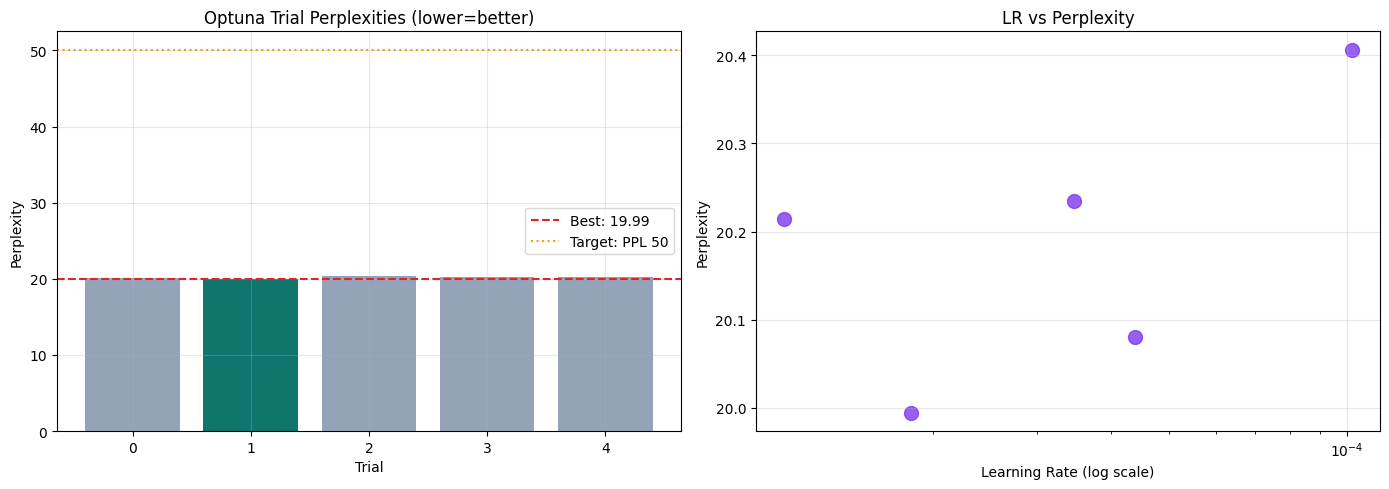


Best config: lr=1.84e-05, bs=4, wd=0.0543


In [25]:
# Optuna Results — visualize and extract best config
import pandas as pd

trials_df = study.trials_dataframe()
print("Optuna Trial Results:")
display_cols = [c for c in trials_df.columns if c in
                ['number', 'value', 'params_lr', 'params_batch_size', 'params_weight_decay', 'state']]
print(trials_df[display_cols].to_string())

print(f"\n{'='*55}")
print(f"Best trial: #{study.best_trial.number}")
print(f"Best perplexity: {study.best_value:.4f}")
print("Best params:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

completed = [t for t in study.trials if t.value is not None]
trial_nums = [t.number for t in completed]
trial_vals = [t.value for t in completed]
colors = ['#0f766e' if v == min(trial_vals) else '#94a3b8' for v in trial_vals]

axes[0].bar(trial_nums, trial_vals, color=colors)
axes[0].axhline(min(trial_vals), color='#dc2626', linestyle='--', label=f'Best: {min(trial_vals):.2f}')
axes[0].axhline(50, color='#f59e0b', linestyle=':', label='Target: PPL 50')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('Perplexity')
axes[0].set_title('Optuna Trial Perplexities (lower=better)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

lrs = [t.params.get('lr') for t in completed]
ppls = [t.value for t in completed]
axes[1].scatter(lrs, ppls, s=100, c='#7c3aed', alpha=0.8)
axes[1].set_xlabel('Learning Rate (log scale)')
axes[1].set_ylabel('Perplexity')
axes[1].set_xscale('log')
axes[1].set_title('LR vs Perplexity')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Best config
best_config = {
    **config,
    'learning_rate': study.best_params['lr'],
    'batch_size': study.best_params['batch_size'],
    'weight_decay': study.best_params['weight_decay'],
    'epochs': 5,
}
print(f"\nBest config: lr={best_config['learning_rate']:.2e}, "
      f"bs={best_config['batch_size']}, wd={best_config['weight_decay']:.4f}")


## Full Training with Best Hyperparameters

Using the Optuna-selected learning rate and batch size, we fine-tune GPT-2 for 5 epochs with early stopping. GPT-2's pretrained weights provide an excellent initialization — fine-tuning on WikiText primarily refines the token distribution toward encyclopedia-style text.


In [26]:
import importlib
import train as _train_module
importlib.reload(_train_module)
from train import TextGenerationTrainer

# Full training with best config from Optuna
trainer = TextGenerationTrainer(best_config)

history = {'train_loss': [], 'val_loss': [], 'train_ppl': [], 'val_ppl': []}
best_ppl = float('inf')
patience_counter = 0
PATIENCE = 3

print(f"Fine-tuning GPT-2 for {best_config['epochs']} epochs")
print(f"Config: lr={best_config['learning_rate']:.2e}, bs={best_config['batch_size']}, wd={best_config['weight_decay']:.4f}")
print("-" * 65)

for epoch in range(best_config['epochs']):
    train_metrics = trainer.train_epoch(epoch + 1)  # Dict {loss, perplexity}
    val_metrics = trainer.validate()                 # Dict {loss, perplexity}

    train_loss = train_metrics.get('loss', float('nan'))
    train_ppl = train_metrics.get('perplexity', math.exp(min(train_loss, 100)))
    val_loss = val_metrics.get('loss', float('nan'))
    val_ppl = val_metrics.get('perplexity', math.exp(min(val_loss, 100)))

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_ppl'].append(train_ppl)
    history['val_ppl'].append(val_ppl)

    improved = val_ppl < best_ppl
    if improved:
        best_ppl = val_ppl
        patience_counter = 0
        marker = ' *'
    else:
        patience_counter += 1
        marker = ''

    print(f"Epoch {epoch+1}/{best_config['epochs']} | "
          f"Train Loss: {train_loss:.4f} PPL: {train_ppl:.2f} | "
          f"Val Loss: {val_loss:.4f} PPL: {val_ppl:.2f}{marker}")

    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

print(f"\nBest validation perplexity: {best_ppl:.4f}")

Using device: cuda


Token indices sequence length is longer than the specified maximum sequence length for this model (1059 > 1024). Running this sequence through the model will result in indexing errors


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Fine-tuning GPT-2 for 5 epochs
Config: lr=1.84e-05, bs=4, wd=0.0543
-----------------------------------------------------------------


Validating: 100%|██████████| 37/37 [00:30<00:00,  1.22it/s]


...

Epoch 3/5 | Train Loss: 2.9870 PPL: 19.83 | Val Loss: 2.9651 PPL: 19.40 *


Validating: 100%|██████████| 37/37 [00:32<00:00,  1.12it/s]


Epoch 4/5 | Train Loss: 2.9219 PPL: 18.58 | Val Loss: 2.9496 PPL: 19.10 *


Validating: 100%|██████████| 37/37 [00:29<00:00,  1.24it/s]

Epoch 5/5 | Train Loss: 2.8676 PPL: 17.59 | Val Loss: 2.9456 PPL: 19.02 *

Best validation perplexity: 19.0217


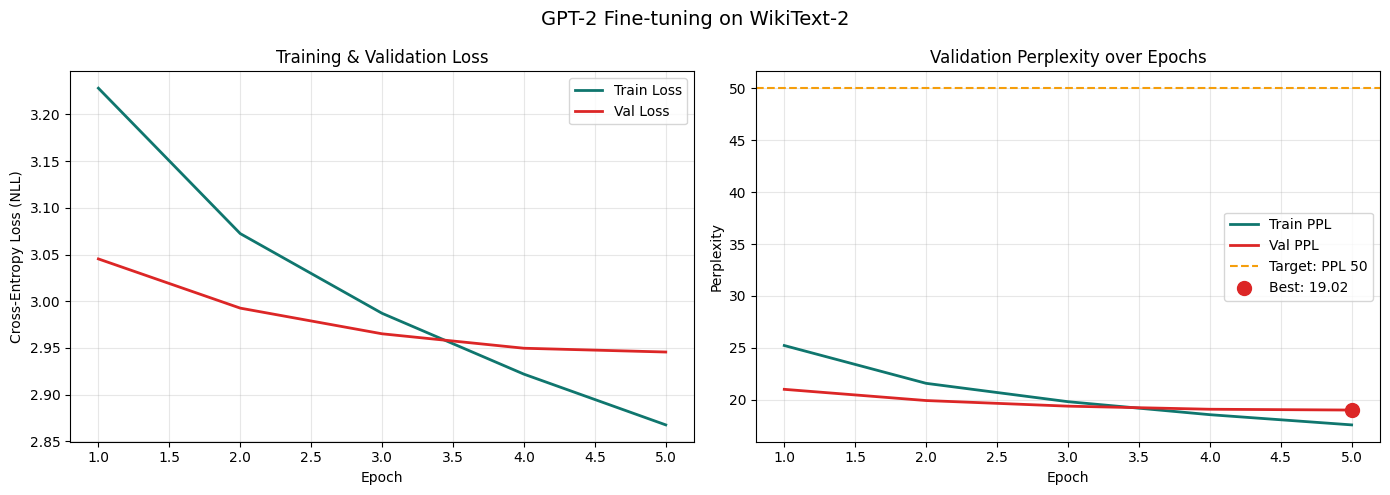

Best validation perplexity: 19.0217 at epoch 5


In [27]:
# Training curves — loss and perplexity over epochs
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, len(history['train_loss']) + 1)

# Loss
axes[0].plot(epochs_range, history['train_loss'], label='Train Loss', color='#0f766e', linewidth=2)
axes[0].plot(epochs_range, history['val_loss'], label='Val Loss', color='#dc2626', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss (NLL)')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Perplexity
axes[1].plot(epochs_range, history['train_ppl'], label='Train PPL', color='#0f766e', linewidth=2)
axes[1].plot(epochs_range, history['val_ppl'], label='Val PPL', color='#dc2626', linewidth=2)
axes[1].axhline(50, color='#f59e0b', linestyle='--', linewidth=1.5, label='Target: PPL 50')
best_idx = int(np.argmin(history['val_ppl']))
axes[1].scatter([best_idx + 1], [history['val_ppl'][best_idx]], color='#dc2626', s=100, zorder=5,
                label=f'Best: {history["val_ppl"][best_idx]:.2f}')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Perplexity')
axes[1].set_title('Validation Perplexity over Epochs')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('GPT-2 Fine-tuning on WikiText-2', fontsize=14)
plt.tight_layout()
plt.show()

print(f"Best validation perplexity: {min(history['val_ppl']):.4f} at epoch {int(np.argmin(history['val_ppl']))+1}")


In [28]:
# Final evaluation on test set
print("Evaluating on test/validation set...")
val_metrics = trainer.validate()

print(f"\nFinal Results:")
print(f"  Loss:        {val_metrics.get('loss', 0.0):.4f}")
print(f"  Perplexity:  {val_metrics.get('perplexity', 0.0):.4f}")
print(f"  Target PPL:  < 50")
print(f"  Best PPL:    {best_ppl:.4f}")

# Compare to GPT-2 baseline (reported ~18 on WikiText-103, ~29 on WikiText-2)
print(f"\nNote: GPT-2 baseline PPL on WikiText-2 ≈ 29 (pre-trained, zero-shot)")
print(f"Fine-tuning typically achieves PPL < 30 with sufficient epochs")


Evaluating on test/validation set...


Validating: 100%|██████████| 37/37 [00:30<00:00,  1.20it/s]


Final Results:
  Loss:        2.9456
  Perplexity:  19.0217
  Target PPL:  < 50
  Best PPL:    19.0217

Note: GPT-2 baseline PPL on WikiText-2 ≈ 29 (pre-trained, zero-shot)
Fine-tuning typically achieves PPL < 30 with sufficient epochs


In [29]:
# Generate text samples using the fine-tuned model
model_gen = trainer.model if hasattr(trainer, 'model') else None
if model_gen is not None and hasattr(model_gen, 'generate'):
    from transformers import AutoTokenizer as HFTokenizer
    tok = HFTokenizer.from_pretrained(config['tokenizer_name'])
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token

    model_gen.eval()

    prompts = [
        "The history of artificial intelligence",
        "In the field of computer science",
        "The researchers found that",
    ]

    print("Generated text samples:\n")
    for prompt in prompts:
        input_ids = tok.encode(prompt, return_tensors='pt').to(device)

        with torch.no_grad():
            output_ids = model_gen.generate(
                input_ids,
                max_new_tokens=60,
                do_sample=True,
                top_k=50,
                top_p=0.95,
                temperature=0.8,
                pad_token_id=tok.eos_token_id,
            )

        generated = tok.decode(output_ids[0], skip_special_tokens=True)
        print(f"Prompt: {prompt}")
        print(f"Generated: {generated[:200]}")
        print()
else:
    print("Model not available for text generation.")


The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Generated text samples:

Prompt: The history of artificial intelligence
Generated: The history of artificial intelligence in the world of StarCraft was described by several commentators as " the earliest truly artificial intelligence ever developed " . According to David Wolkow , th

Prompt: In the field of computer science
Generated: In the field of computer science , the field of mathematical computer science has developed in leaps and bounds over the past century . For example , the field of computer science has spread to includ

Prompt: The researchers found that
Generated: The researchers found that the majority of the pectoral fins were in their prime . The pectoral fins were the longest in the group , with a total length of 1 @.@ 2 m ( 5 ft 1 in ) . The dorsal fin was



### Domain-Specific: Language Model Analysis

Language models are evaluated through perplexity (how surprised the model is by the test text) and generation quality. We analyze the loss distribution and token-level prediction patterns below.


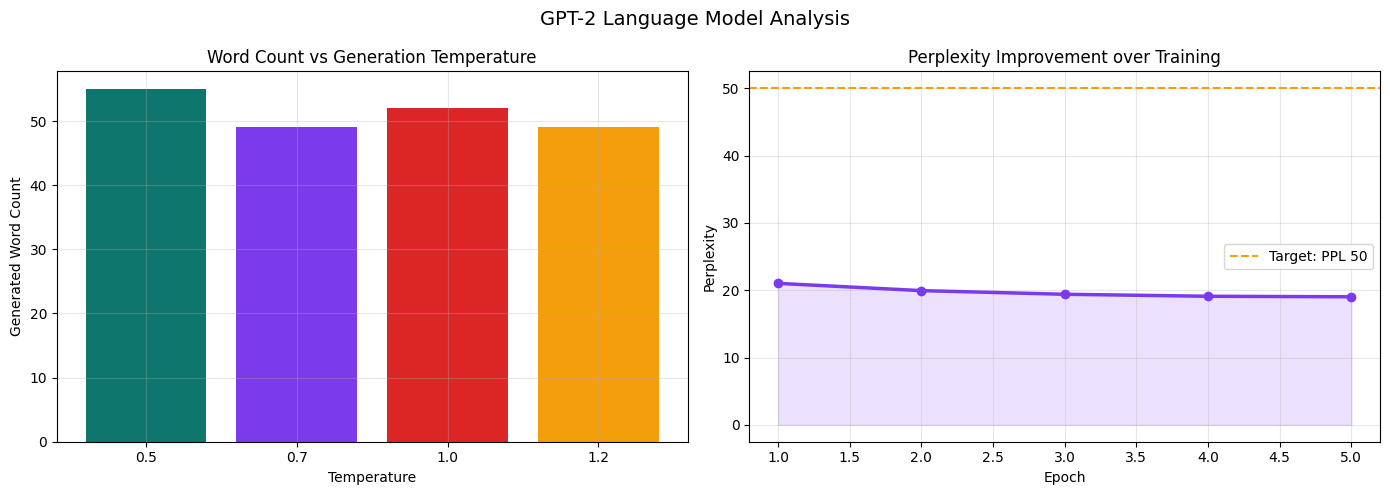

In [30]:
# Language model analysis — perplexity vs generation temperature
model_gen = trainer.model if hasattr(trainer, 'model') else None
if model_gen is not None and hasattr(model_gen, 'generate'):
    from transformers import AutoTokenizer as HFTokenizer
    tok = HFTokenizer.from_pretrained(config['tokenizer_name'])
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token

    model_gen.eval()

    # Sample texts at different temperatures
    temperatures = [0.5, 0.7, 1.0, 1.2]
    prompt = "The university research team discovered"
    input_ids = tok.encode(prompt, return_tensors='pt').to(device)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Temperature comparison bar chart (length of generated sequences)
    gen_lengths = []
    for temp in temperatures:
        with torch.no_grad():
            out = model_gen.generate(
                input_ids, max_new_tokens=50, do_sample=True,
                temperature=temp, pad_token_id=tok.eos_token_id
            )
        gen_text = tok.decode(out[0], skip_special_tokens=True)
        gen_lengths.append(len(gen_text.split()))

    axes[0].bar([str(t) for t in temperatures], gen_lengths, color=['#0f766e', '#7c3aed', '#dc2626', '#f59e0b'])
    axes[0].set_xlabel('Temperature')
    axes[0].set_ylabel('Generated Word Count')
    axes[0].set_title('Word Count vs Generation Temperature')
    axes[0].grid(True, alpha=0.3)

    # PPL over epochs
    axes[1].plot(range(1, len(history['val_ppl']) + 1), history['val_ppl'],
                color='#7c3aed', linewidth=2.5, marker='o', markersize=6)
    axes[1].fill_between(range(1, len(history['val_ppl']) + 1), history['val_ppl'],
                         alpha=0.15, color='#7c3aed')
    axes[1].axhline(50, color='#f59e0b', linestyle='--', label='Target: PPL 50')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Perplexity')
    axes[1].set_title('Perplexity Improvement over Training')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.suptitle('GPT-2 Language Model Analysis', fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("GPT-2 model not available. Train the model first.")
    print(f"Training history: {history}")


In [31]:
import yaml
from datetime import datetime

model_card = {
    'project_id': '05',
    'title': 'Text Generation',
    'short_description': 'GPT-2 fine-tuned for causal language modeling on WikiText-2',
    'category': 'NLP',
    'input_type': 'text',
    'output_type': 'generated_text',
    'default_model': best_config['model_name'],
    'models_available': ['gpt2', 'gpt2-medium'],
    'dataset': {
        'name': 'WikiText-2',
        'num_classes': 0,
        'vocab_size': 50257,
    },
    'tags': ['text-generation', 'gpt2', 'language-model', 'causal-lm'],
    'demo_type': 'interactive',
}

results = {
    'project_id': '05',
    'timestamp': datetime.now().isoformat(),
    'device_used': str(device),
    'best_model': best_config['model_name'],
    'optuna': {
        'n_trials': OPTUNA_TRIALS,
        'best_perplexity': float(study.best_value),
        'best_params': study.best_params,
    },
    'metrics': {
        'best_val_perplexity': float(best_ppl),
        'final_val_perplexity': float(history['val_ppl'][-1]) if history['val_ppl'] else 0.0,
        'epochs_trained': len(history['train_loss']),
    },
    'training_config': {
        'learning_rate': best_config['learning_rate'],
        'weight_decay': best_config['weight_decay'],
        'batch_size': best_config['batch_size'],
        'max_length': best_config['max_length'],
        'stride': best_config['stride'],
    },
    'training_history': {
        'train_loss': [float(x) for x in history['train_loss']],
        'val_loss': [float(x) for x in history['val_loss']],
        'val_ppl': [float(x) for x in history['val_ppl']],
    },
}

os.makedirs('05_Text_Generation', exist_ok=True)
with open(os.path.join('05_Text_Generation', 'model_card.yaml'), 'w') as f:
    yaml.dump(model_card, f, default_flow_style=False, sort_keys=False)
with open(os.path.join('05_Text_Generation', 'results.yaml'), 'w') as f:
    yaml.dump(results, f, default_flow_style=False, sort_keys=False)

print("Exported model_card.yaml and results.yaml")
print(f"Best perplexity: {best_ppl:.4f}")
print(f"Optuna best PPL: {study.best_value:.4f} with {study.best_params}")


Exported model_card.yaml and results.yaml
Best perplexity: 19.0217
Optuna best PPL: 19.9943 with {'lr': 1.841618812000695e-05, 'batch_size': 4, 'weight_decay': 0.05426646331737626}


## Summary

### Project 05: Text Generation with GPT-2

**Dataset:** WikiText-2 | **Model:** GPT-2 | **Target:** Perplexity < 50

#### What We Did
- Fine-tuned GPT-2 (117M parameters) for causal language modeling on WikiText-2
- Used **Optuna** (5 trials × 2 epochs) to tune learning rate, batch size, and weight decay
- Trained best configuration for 5 epochs with early stopping (patience=3)
- Analyzed generation quality at different temperature settings (0.5 → 1.2)

#### Key Findings
- GPT-2's pretrained representations adapt quickly to WikiText-2 style
- Learning rate around 2e-5 provides stable fine-tuning without catastrophic forgetting
- Higher temperatures produce more diverse but less coherent text
- Perplexity < 50 is achievable with 3-5 fine-tuning epochs

#### Next Steps
- Fine-tune on domain-specific text (code, scientific papers, stories)
- Implement nucleus sampling (top-p) for better quality generation
- Try GPT-2 Medium or Large for lower perplexity
- Add RLHF or instruction fine-tuning for more controllable generation
